<a href="https://colab.research.google.com/github/Aditi-dev07/Cisco_DataScience_Projects/blob/main/Data%20Modeling/Poison%20dart%20frogs/poison-dart-frogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Poison dart frogs

Can you estimate how toxic a poison dart frog is based on its brightness?

Poison dart frogs are small, colorful frogs from Central and South America. They're famous for their toxic skin, which some indigenous people use for blow darts.

Scientists studied the connection between the bright colors and toxicity of the poison dart frog **Dendrobates pumilio**. While they're usually red with blue legs, they can be found in about 15 different colors in Panama.

The file `frog-reflectance.csv` contains the average brightness (from 0 to 1) of 10 frog populations, measured on both the back and belly.

The file `frog-toxicity.csv` provides a `toxicity` score (from 0 to 1) for 48 frogs from the same 10 populations. Toxicity was tested by injecting frog skin extracts into mice and recording how long it took them to fall back asleep. Longer times suggest higher `toxicity`.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'frog-reflectance.csv', 'frog-toxicity.csv', and 'linear_model.py'.

from google.colab import files
ploaded = files.upload()

Saving frog-reflectance.csv to frog-reflectance.csv
Saving frog-toxicity.csv to frog-toxicity.csv
Saving linear_model.py to linear_model.py


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('frog-reflectance.csv')
df.head()

,pop_id,back_brightness,belly_brightness
0,AG,0.43,0.46
1,AL,0.64,0.42
2,BCG,1.00,0.95
3,BCO,0.82,1.00
4,CA,0.46,0.51


In [24]:
tox = pd.read_csv('frog-toxicity.csv')
tox.head()

,pop_id,frog_id,toxicity
0,BCO,BC167,0.886925
1,BCO,BC166,0.803917
2,BCO,BC171,0.625008
3,BCO,BC169,0.975847
4,BCO,BC165,0.774033


# Project Ideas

- Build two linear models:
	- Model 1: `toxicity` (x-axis) vs. `back_brightness`

	- Model 2: `toxicity` vs. `belly_brightness`

- To create the models, first calculate the average `toxicity` for each `pop_id`, then merge these values into the main dataframe (`df`).

- Visualize the data by creating scatter plots with best-fit lines for both models.

- Compare the goodness of fit between back and belly brightness and explore possible biological explanations for any differences in correlation.


In [ ]:
# YOUR CODE HERE (add additional cells as needed)

# Linear model API

# linear = LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info(self):


#1.Build two linear models

In [25]:
model_1= LinearModel()

avg_toxicity = tox.groupby('pop_id')['toxicity'].mean().reset_index()
df = df.merge(avg_toxicity, on='pop_id')

model_x = df['toxicity']
model_y = df['back_brightness']
x_min = min(model_x)
x_max = max(model_x)
model_1.fit(model_x, model_y)
model_1.print_model_info()

LinearModel():
Slope: 0.5758129980180036
Intercept: 0.3165043254009716
R-squared: 0.6067780219154056


In [28]:
model2 = LinearModel()

model2_x = df['toxicity']
model2_y = df['belly_brightness']
x_min = min(model2_x)
x_max = max(model2_x)
model2.fit(model2_x, model2_y)
model2.print_model_info()

LinearModel():
Slope: 0.34762229493312424
Intercept: 0.3936848861127157
R-squared: 0.18431612963411392


#2.Visualize the data by creating scatter plots with best-fit lines for both models.

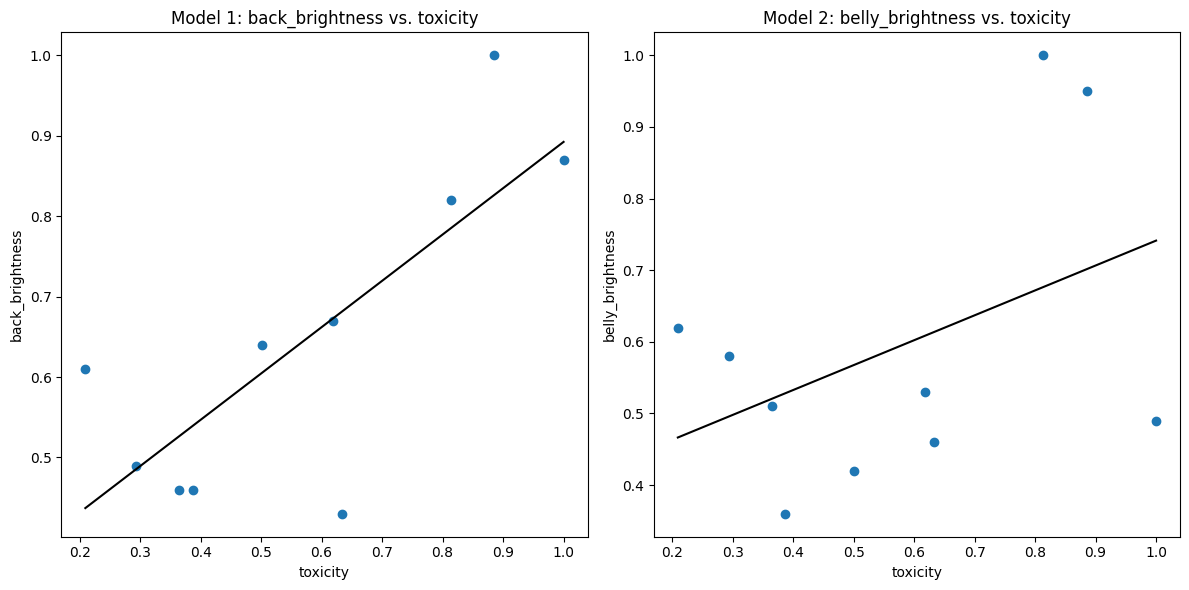

In [33]:
plt.figure(figsize=(12, 6))


plt.subplot(1,2,1)
model_1.plot_model(x_min, x_max, color="black")
plt.scatter(model_x, model_y)
plt.xlabel('toxicity')
plt.ylabel('back_brightness')
plt.title('Model 1: back_brightness vs. toxicity')

plt.subplot(1,2,2)
model2.plot_model(x_min, x_max, color="black")
plt.scatter(model2_x, model2_y)
plt.xlabel('toxicity')
plt.ylabel('belly_brightness')
plt.title('Model 2: belly_brightness vs. toxicity')

plt.tight_layout()
plt.show()


##3.Compare the goodness of fit between back and belly brightness and explore possible biological explanations for any differences in correlation.

### Model Comparison and Biological Explanation

**R-squared values:**

- **Model 1 (Toxicity vs. Back Brightness):** R-squared = 0.607
- **Model 2 (Toxicity vs. Belly Brightness):** R-squared = 0.184

**Goodness of Fit:**

Model 1, which relates `toxicity` to `back_brightness`, has a significantly higher R-squared value (0.607) compared to Model 2 (0.184), which relates `toxicity` to `belly_brightness`. This indicates that **back brightness is a much better predictor of toxicity** than belly brightness.

**Biological Explanation:**

This difference in correlation makes strong biological sense due to the principles of aposematism (warning coloration). Poison dart frogs use their vibrant colors as a visual signal to predators that they are toxic and should be avoided. The **back of the frog is the most visible part** when the frog is active, moving, or resting in its natural habitat, making it the primary surface for displaying this warning signal. Predators are more likely to observe the dorsal (back) coloration of the frog before an encounter.

Conversely, the **belly of the frog is often less exposed or even hidden** when the frog is on the ground, in foliage, or in a defensive posture. Therefore, an evolved warning signal would be most effective if displayed prominently on the most observable parts of the body. A strong correlation between back brightness and toxicity suggests that the intensity of the warning signal (brightness) is directly linked to the level of danger (toxicity) the frog poses, allowing predators to quickly learn and avoid the most toxic individuals based on their visible coloration. The weaker correlation with belly brightness implies that this area plays a lesser role in primary warning signaling, likely because it is less frequently seen by potential threats.